In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuración visual para los Dashboards
sns.set_theme(style="whitegrid", context="talk")

print("Iniciando extracción  de datos ")

#  Cargar Pacientes
columnas_pacientes = ['Cedula', 'Nombre_Paciente', 'Edad_Paciente', 'Telefono', 'Clave']
df_pacientes = pd.read_csv('data_pacientes.txt', sep='|', names=columnas_pacientes, dtype=str)
df_pacientes['Edad_Paciente'] = pd.to_numeric(df_pacientes['Edad_Paciente'])

#  Cargar Médicos
columnas_medicos = ['Codigo_Medico', 'Nombre_Medico', 'Edad_Medico', 'Especialidad', 'Horario', 'Clave']
df_medicos = pd.read_csv('data_medicos.txt', sep='|', names=columnas_medicos, dtype=str)

#  Cargar Citas
columnas_citas = ['ID_Cita', 'Cedula', 'Codigo_Medico', 'Fecha', 'Hora', 'Motivo', 'Estado']
df_citas = pd.read_csv('data_citas.txt', sep='|', names=columnas_citas, dtype=str)
df_citas['Estado'] = pd.to_numeric(df_citas['Estado'])

print(f" ETL Completado: {len(df_pacientes)} Pacientes, {len(df_medicos)} Médicos, {len(df_citas)} Citas extraídas.")

Iniciando extracción masiva de datos (ETL)...
 ETL Completado: 15000 Pacientes, 500 Médicos, 30000 Citas extraídas.


In [3]:
# Mapeo de los 4 estados del TPS
mapa_estados = {0: 'Activa', 1: 'Cancelada', 2: 'Atendida', 3: 'No Asistió'}
df_citas['Estado_Texto'] = df_citas['Estado'].map(mapa_estados)

# MÓDULO FINANCIERO: MULTAS POR INASISTENCIA
PRECIO_INASISTENCIA = 25.00
# Solo el estado 3  genera recaudación
df_citas['Multa_Recaudada'] = df_citas['Estado'].apply(lambda x: PRECIO_INASISTENCIA if x == 3 else 0.0)

# Formateo de fechas para series de tiempo
df_citas['Fecha_DT'] = pd.to_datetime(df_citas['Fecha'], format='%d-%m-%Y', errors='coerce')
df_citas['Mes_Anio'] = df_citas['Fecha_DT'].dt.to_period('M')

# MIS
df_mis = pd.merge(df_citas, df_pacientes[['Cedula', 'Nombre_Paciente', 'Edad_Paciente']], on='Cedula', how='left')
df_mis = pd.merge(df_mis, df_medicos[['Codigo_Medico', 'Nombre_Medico', 'Especialidad', 'Horario']], on='Codigo_Medico', how='left')

# Segmentación Demográfica Real
def segmentar_edad(edad):
    if edad < 18: return 'Adolescentes (13-17)'
    elif edad <= 64: return 'Adultos (18-64)'
    else: return 'Geriátricos (65+)'

df_mis['Segmento_Cliente'] = df_mis['Edad_Paciente'].apply(segmentar_edad)
df_mis['Turno_Asignado'] = df_mis['Horario'].apply(lambda x: 'Turno Mañana' if '08:00' in str(x) else 'Turno Tarde')

print(" Datos transformados y listos para análisis estratégico.")

 Datos transformados y listos para análisis estratégico.


In [4]:
# Cálculos de rutina
citas_activas = len(df_mis[df_mis['Estado'].isin([0, 2])]) # Activas y Atendidas
citas_canceladas = len(df_mis[df_mis['Estado'] == 1])
inasistencias = len(df_mis[df_mis['Estado'] == 3])
recaudacion_total = df_mis['Multa_Recaudada'].sum()

print("==========================================================")
print("  REPORTE GERENCIAL DE RUTINA Y AUDITORÍA FINANCIERA")
print("==========================================================")
print(f" Volumen Total de Transacciones   : {len(df_mis)} citas")
print(f"  Citas Efectivas                 : {citas_activas}")
print(f"  Citas Canceladas                : {citas_canceladas}")
print(f"> Inasistencias                   : {inasistencias}")
print("----------------------------------------------------------")
print(f"  RECAUDACIÓN POR INASISTENCIAS   : ${recaudacion_total:,.2f} USD")
print("==========================================================")
print(" El capital recuperado por inasistencias")
print(" cubre el costo operativo de las horas ociosas.")
print("==========================================================")

  REPORTE GERENCIAL DE RUTINA Y AUDITORÍA FINANCIERA
 Volumen Total de Transacciones   : 30000 citas
  Citas Efectivas                 : 27309
  Citas Canceladas                : 1607
> Inasistencias                   : 1084
----------------------------------------------------------
  RECAUDACIÓN POR INASISTENCIAS   : $27,100.00 USD
 El capital recuperado por inasistencias
 cubre el costo operativo de las horas ociosas.


/tmp/ipykernel_4939/1839202868.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuga_esp.values, y=fuga_esp.index, ax=ax2, palette='Reds_r')
/tmp/ipykernel_4939/1839202868.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Especialidad', data=df_mis, order=df_mis['Especialidad'].value_counts().index, palette='Blues_r', ax=ax3)
/tmp/ipykernel_4939/1839202868.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_medicos.values, y=top_medicos.index, ax=ax4, palette='magma')
/tmp/ipykernel_4939/1839202868.py:44: FutureWarning: 

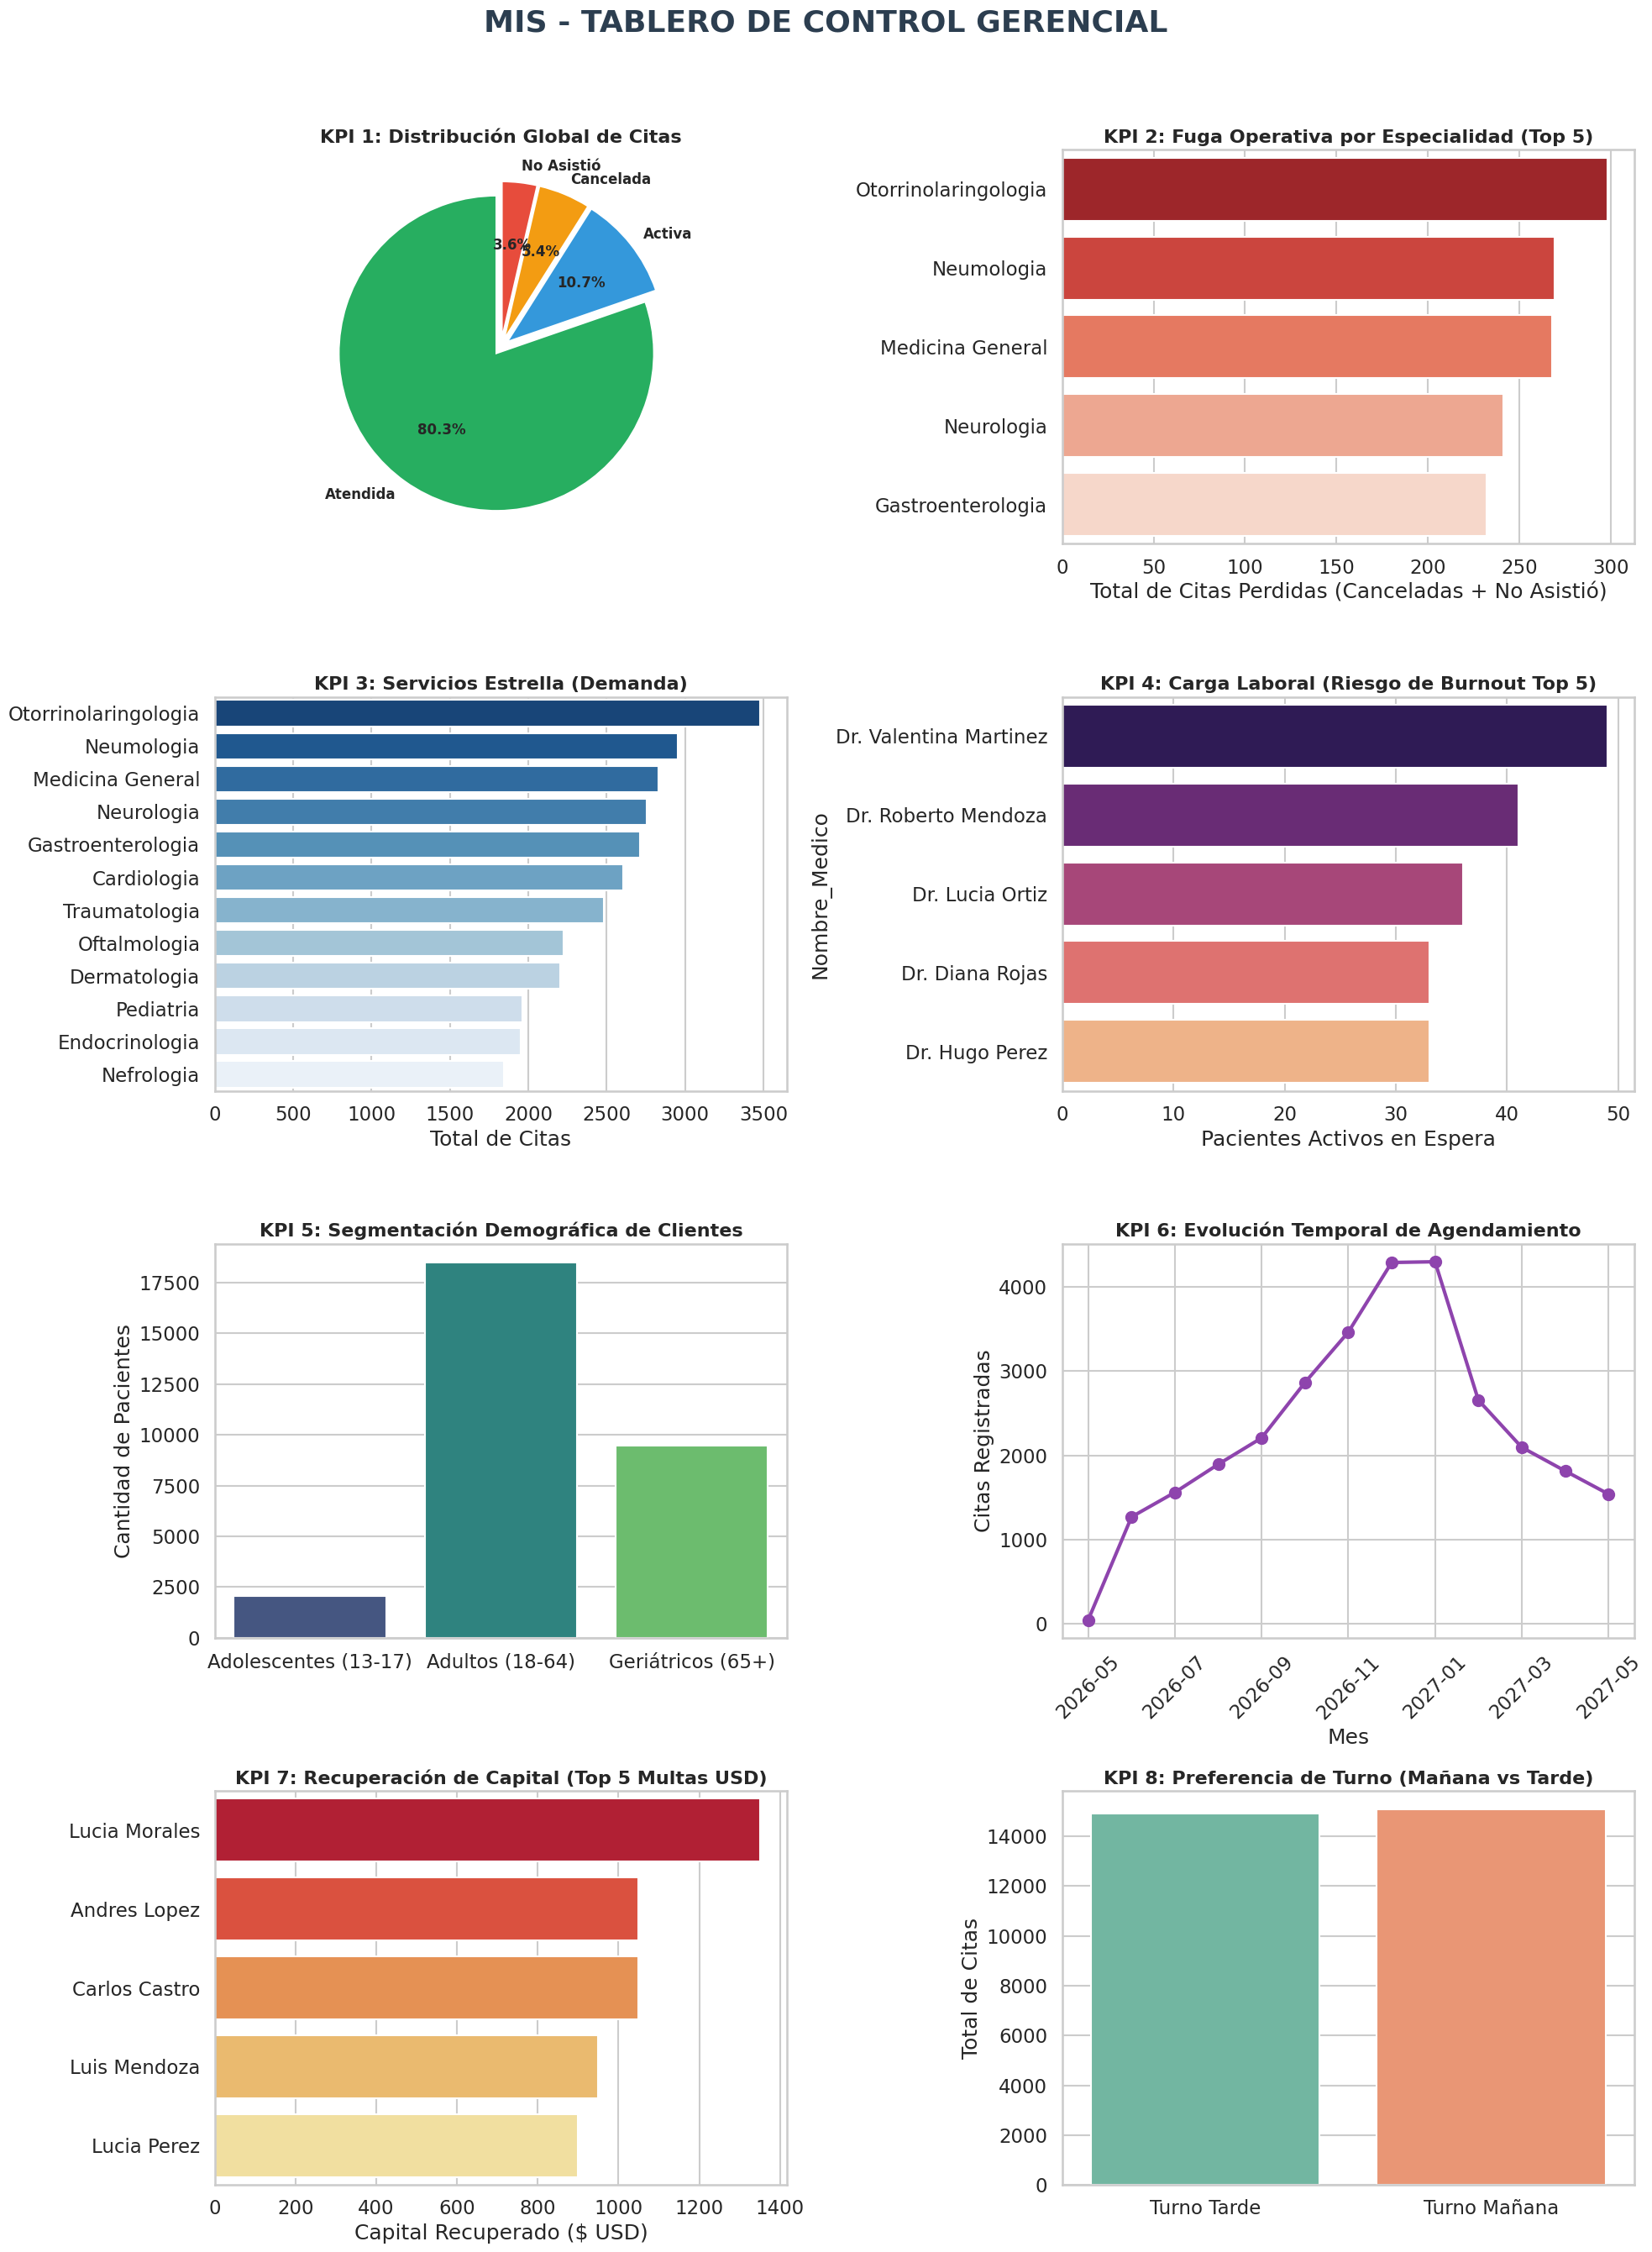

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(20, 28))
fig.suptitle('MIS - TABLERO DE CONTROL GERENCIAL', fontsize=26, fontweight='bold', color='#2c3e50', y=0.98)


# KPI 1: DISTRIBUCIÓN GLOBAL DE CITAS (TASA DE EFECTIVIDAD DESGLOSADA)
ax1 = axes[0, 0]
dist_estados = df_mis['Estado_Texto'].value_counts()
colores_est = {'Atendida': '#27ae60', 'Activa': '#3498db', 'No Asistió': '#e74c3c', 'Cancelada': '#f39c12'}
colores_plot = [colores_est.get(x, '#bdc3c7') for x in dist_estados.index]

ax1.pie(dist_estados, labels=dist_estados.index, autopct='%1.1f%%', colors=colores_plot, startangle=90, explode=[0.05]*len(dist_estados), textprops={'fontsize': 12, 'weight': 'bold'})
ax1.set_title('KPI 1: Distribución Global de Citas', fontweight='bold', fontsize=16)


# KPI 2: FUGA OPERATIVA POR ESPECIALIDAD
ax2 = axes[0, 1]
fuga_df = df_mis[df_mis['Estado'].isin([1, 3])]
fuga_esp = fuga_df['Especialidad'].value_counts().head(5)
sns.barplot(x=fuga_esp.values, y=fuga_esp.index, ax=ax2, palette='Reds_r')
ax2.set_title('KPI 2: Fuga Operativa por Especialidad (Top 5)', fontweight='bold', fontsize=16)
ax2.set_xlabel('Total de Citas Perdidas (Canceladas + No Asistió)')
ax2.set_ylabel('')


# KPI 3: DEMANDA POR ESPECIALIDAD (MEDICINA GENERAL LIDERANDO)
ax3 = axes[1, 0]
sns.countplot(y='Especialidad', data=df_mis, order=df_mis['Especialidad'].value_counts().index, palette='Blues_r', ax=ax3)
ax3.set_title('KPI 3: Servicios Estrella (Demanda)', fontweight='bold', fontsize=16)
ax3.set_xlabel('Total de Citas')
ax3.set_ylabel('')


# KPI 4: CARGA LABORAL MÉDICA
ax4 = axes[1, 1]
citas_activas = df_mis[df_mis['Estado'] == 0]
top_medicos = citas_activas['Nombre_Medico'].value_counts().head(5)
sns.barplot(x=top_medicos.values, y=top_medicos.index, ax=ax4, palette='magma')
ax4.set_title('KPI 4: Carga Laboral (Riesgo de Burnout Top 5)', fontweight='bold', fontsize=16)
ax4.set_xlabel('Pacientes Activos en Espera')


# KPI 5: DISTRIBUCIÓN DEMOGRÁFICA
ax5 = axes[2, 0]
sns.countplot(x='Segmento_Cliente', data=df_mis, order=['Adolescentes (13-17)', 'Adultos (18-64)', 'Geriátricos (65+)'], palette='viridis', ax=ax5)
ax5.set_title('KPI 5: Segmentación Demográfica de Clientes', fontweight='bold', fontsize=16)
ax5.set_xlabel('')
ax5.set_ylabel('Cantidad de Pacientes')


# KPI 6: EVOLUCIÓN MENSUAL DE LA DEMANDA
ax6 = axes[2, 1]
tendencia = df_mis.groupby('Mes_Anio').size().sort_index()
tendencia.index = tendencia.index.astype(str)
tendencia.plot(kind='line', marker='o', ax=ax6, color='#8e44ad', linewidth=3, markersize=10)
ax6.set_title('KPI 6: Evolución Temporal de Agendamiento', fontweight='bold', fontsize=16)
ax6.set_ylabel('Citas Registradas')
ax6.set_xlabel('Mes')
ax6.tick_params(axis='x', rotation=45)


# KPI 7: RECUPERACIÓN DE CAPITAL (NUEVO - TOP 5 MULTAS)
ax7 = axes[3, 0]
inasistencias = df_mis[df_mis['Estado'] == 3]
# Multiplicamos el conteo de inasistencias por $50 USD de multa por cada falta
multas_pacientes = inasistencias['Nombre_Paciente'].value_counts().head(5) * 50

sns.barplot(x=multas_pacientes.values, y=multas_pacientes.index, ax=ax7, palette='YlOrRd_r')
ax7.set_title('KPI 7: Recuperación de Capital (Top 5 Multas USD)', fontweight='bold', fontsize=16)
ax7.set_xlabel('Capital Recuperado ($ USD)')
ax7.set_ylabel('')


# KPI 8: DEMANDA POR TURNO LABORAL
ax8 = axes[3, 1]
sns.countplot(x='Turno_Asignado', data=df_mis, palette='Set2', ax=ax8)
ax8.set_title('KPI 8: Preferencia de Turno (Mañana vs Tarde)', fontweight='bold', fontsize=16)
ax8.set_xlabel('')
ax8.set_ylabel('Total de Citas')

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()